# CPJUMP1 → AnnData

Builds an AnnData object from the CellProfiler well-level profiles of [CPJUMP1](https://github.com/jump-cellpainting/2024_Chandrasekaran_NatureMethods_CPJUMP1) ([Chandrasekaran et al. 2024](https://www.nature.com/articles/s41592-024-02241-6)).
One observation is a well, one variable is a CellProfiler feature.

The profiles are stored in Git LFS, so a plain `git clone` yields pointer stubs:

```bash
git clone https://github.com/jump-cellpainting/2024_Chandrasekaran_NatureMethods_CPJUMP1
cd 2024_Chandrasekaran_NatureMethods_CPJUMP1 && git lfs pull
```

In [1]:
from __future__ import annotations

from collections.abc import Iterable, Sequence
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

DATA_ROOT = Path("~/data/2024_Chandrasekaran_NatureMethods_CPJUMP1").expanduser()
BATCH = "2020_11_04_CPJUMP1"
VARIANT = "normalized_feature_select_negcon_batch"

## Loading a batch

Each plate ships seven variants of the same wells.
`normalized_feature_select_negcon_batch` is MAD-robustized against the negative controls and feature selected, and is what the paper benchmarks on.

Feature selection ran per batch, so variables are identical across plates within a batch but differ between batches.
Combining batches requires intersecting variables first.

In [2]:
def load_batch(root: Path, batch: str, variant: str = VARIANT) -> ad.AnnData:
    files = sorted((root / "profiles" / batch).glob(f"*/*_{variant}.csv.gz"))
    if not files:
        raise FileNotFoundError(f"no {variant!r} profiles under {root / 'profiles' / batch}")

    frames = [pd.read_csv(f) for f in files]
    if len({tuple(frame.columns) for frame in frames}) > 1:
        raise ValueError("plates disagree on columns; intersect features before concatenating")

    df = pd.concat(frames, ignore_index=True)
    meta_cols = [c for c in df.columns if c.startswith("Metadata_")]
    feature_cols = [c for c in df.columns if c not in meta_cols]

    obs = df[meta_cols].rename(columns=lambda c: c.removeprefix("Metadata_"))
    obs.index = pd.Index(obs["Plate"].astype(str) + ":" + obs["Well"].astype(str), name="well")
    var = pd.DataFrame(index=pd.Index(feature_cols, name="feature"))

    return ad.AnnData(X=df[feature_cols].to_numpy(np.float32), obs=obs, var=var)


adata = load_batch(DATA_ROOT, BATCH)
adata

AnnData object with n_obs × n_vars = 19498 × 904
    obs: 'broad_sample', 'solvent', 'Plate', 'Well', 'InChIKey', 'pert_iname', 'pubchem_cid', 'gene', 'pert_type', 'control_type', 'smiles', 'target_sequence', 'negcon_control_type'
    layers: None (.X)

## Plate design

The profiles carry per-well perturbation annotation only.
`experiment-metadata.tsv` adds the design of each plate.

In [3]:
def add_plate_design(adata: ad.AnnData, root: Path, batch: str) -> None:
    design = (
        pd.read_csv(root / "experiment-metadata.tsv", sep="\t")
        .query("Batch == @batch")
        .set_index("Assay_Plate_Barcode")
    )
    columns = ["Perturbation", "Cell_type", "Time", "Density", "Antibiotics", "Cell_line", "Anomaly"]
    adata.obs = adata.obs.join(design[columns].rename(columns=str.lower), on="Plate")
    adata.uns["batch"] = batch


def categorize(adata: ad.AnnData, columns: Iterable[str]) -> None:
    for column in columns:
        adata.obs[column] = adata.obs[column].astype("category")


add_plate_design(adata, DATA_ROOT, BATCH)
categorize(adata, ["Plate", "pert_type", "control_type", "perturbation", "cell_type", "time"])
adata.obs.head()

,broad_sample,solvent,Plate,Well,InChIKey,pert_iname,pubchem_cid,gene,pert_type,control_type,smiles,target_sequence,negcon_control_type,perturbation,cell_type,time,density,antibiotics,cell_line,anomaly
well,,,,,,,,,,,,,,,,,,,,
BR00116991:A01,BRD-A86665761-001-01-1,DMSO,BR00116991,A01,TZDUHAJSIBHXDL-UHFFFAOYSA-N,gabapentin-enacarbil,9883900.0,CACNB4,trt,NaN,CC(C)C(=O)OC(C)OC(=O)NCC1(CC(O)=O)CCCCC1,NaN,NaN,compound,A549,24,100,absent,Parental,WGA
BR00116991:A02,NaN,DMSO,BR00116991,A02,IAZDPXIOMUYVGZ-UHFFFAOYSA-N,DMSO,679.0,NaN,control,negcon,CS(=O)C,NaN,NaN,compound,A549,24,100,absent,Parental,WGA
BR00116991:A03,BRD-A22032524-074-09-9,DMSO,BR00116991,A03,HTIQEAQVCYTUBX-UHFFFAOYSA-N,amlodipine,2162.0,CACNA2D3,trt,NaN,CCOC(=O)C1=C(COCCN)NC(C)=C(C1c1ccccc1Cl)C(=O)OC,NaN,NaN,compound,A549,24,100,absent,Parental,WGA
BR00116991:A04,BRD-A01078468-001-14-8,DMSO,BR00116991,A04,PBBGSZCBWVPOOL-UHFFFAOYSA-N,hexestrol,3606.0,AKR1C1,trt,NaN,CCC(C(CC)c1ccc(O)cc1)c1ccc(O)cc1,NaN,NaN,compound,A549,24,100,absent,Parental,WGA
BR00116991:A05,BRD-K48278478-001-01-2,DMSO,BR00116991,A05,LOUPRKONTZGTKE-AFHBHXEDSA-N,quinine,94175.0,KCNN4,trt,NaN,COc1ccc2nccc([C@@H](O)[C@H]3C[C@@H]4CC[N@]3C[C...,NaN,NaN,compound,A549,24,100,absent,Parental,WGA


## Feature annotation

`adata.var` is the annotation table aligned to the variable axis, which is itself one-dimensional (`adata.var_names`).
These columns are derived from the feature names alone and can be dropped without touching the matrix.

CellProfiler names follow `<compartment>_<family>_<measurement>[_<channel>][_<parameters>]`.
Compartment and family are read positionally; channels are the name tokens matching a known channel.
`Correlation` features measure colocalization between a channel *pair*, so two channel columns are needed.
`AreaShape` and `Neighbors` are geometry and have no channel.

The measurement and its parameters (texture scale and angle, granularity scale, radial bin) are not extracted.

In [4]:
CHANNELS: Sequence[str] = ("DNA", "RNA", "AGP", "ER", "Mito", "Brightfield", "LowZBF", "HighZBF")


def annotate_features(var: pd.DataFrame, channels: Sequence[str] = CHANNELS) -> None:
    tokens = [name.split("_") for name in var.index]
    matched = [[t for t in token if t in channels] for token in tokens]
    var["compartment"] = pd.Categorical([t[0] for t in tokens])
    var["family"] = pd.Categorical([t[1] if len(t) > 1 else "" for t in tokens])
    var["channel"] = pd.Categorical([c[0] if c else None for c in matched])
    var["channel_2"] = pd.Categorical([c[1] if len(c) > 1 else None for c in matched])
    var["n_channels"] = np.array([len(c) for c in matched], dtype=np.int8)


annotate_features(adata.var)
adata.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Cells_AreaShape_BoundingBoxMaximum_Y,Cells,AreaShape,NaN,NaN,0
Cells_AreaShape_Compactness,Cells,AreaShape,NaN,NaN,0
Cells_AreaShape_Eccentricity,Cells,AreaShape,NaN,NaN,0
Cells_AreaShape_Extent,Cells,AreaShape,NaN,NaN,0
Cells_AreaShape_Solidity,Cells,AreaShape,NaN,NaN,0
...,...,...,...,...,...
Nuclei_Texture_SumAverage_LowZBF_10_00_256,Nuclei,Texture,LowZBF,NaN,1
Nuclei_Texture_SumVariance_Brightfield_5_00_256,Nuclei,Texture,Brightfield,NaN,1
Nuclei_Texture_SumVariance_ER_10_03_256,Nuclei,Texture,ER,NaN,1


`Cells_Parent_Nuclei` is the object index of each cell's parent nucleus, not a phenotypic measurement.
It survived the published feature selection, so drop it.

In [5]:
adata = adata[:, adata.var["family"] != "Parent"].copy()

## Sanity checks

Well counts vary because a few plates had only a subset of wells imaged.

In [6]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features across {adata.obs['Plate'].nunique()} plates")
print(f"wells per plate: {sorted(adata.obs['Plate'].value_counts().unique())}")
print(f"non-finite values: {int((~np.isfinite(adata.X)).sum())}")
print(adata.obs.groupby("perturbation", observed=True)["cell_type"].value_counts())

19,498 wells x 903 features across 51 plates
wells per plate: [np.int64(301), np.int64(383), np.int64(384)]
non-finite values: 0
perturbation  cell_type
compound      A549         6142
              U2OS         2989
crispr        A549         3839
              U2OS         3072
orf           A549         1920
              U2OS         1536
Name: count, dtype: int64


In [7]:
adata.write_h5ad(DATA_ROOT / f"cpjump1_{BATCH}.h5ad")

## UMAP

The profiles are already MAD-normalized per feature, so they enter PCA unscaled.

In [8]:
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


A UMAP of these profiles is easy to over-read, so measure the structure before looking at it.
How often do neighbouring wells share a label, against the rate expected if labels were shuffled?

In [9]:
def neighbour_enrichment(adata: ad.AnnData, keys: Iterable[str]) -> pd.DataFrame:
    graph = adata.obsp["connectivities"].tocoo()
    rows = []
    for key in keys:
        labels = adata.obs[key].to_numpy()
        observed = float((labels[graph.row] == labels[graph.col]).mean())
        baseline = float((adata.obs[key].value_counts(normalize=True).to_numpy() ** 2).sum())
        rows.append({"covariate": key, "observed": observed, "baseline": baseline, "ratio": observed / baseline})
    return pd.DataFrame(rows).set_index("covariate").round(3)


neighbour_enrichment(adata, ["Plate", "cell_type", "perturbation", "time"])

,observed,baseline,ratio
covariate,,,
Plate,0.142,0.020,7.257
cell_type,0.825,0.524,1.573
perturbation,0.655,0.376,1.741
time,0.530,0.283,1.875


Every covariate is enriched above chance, plate by far the most relative to its baseline.
The geometry tracks experimental design and plate effects rather than perturbation biology, which is why the paper scores retrieval against matched negative controls instead of clustering.

The embedding shows this as one large mass with scattered satellites rather than separated groups.

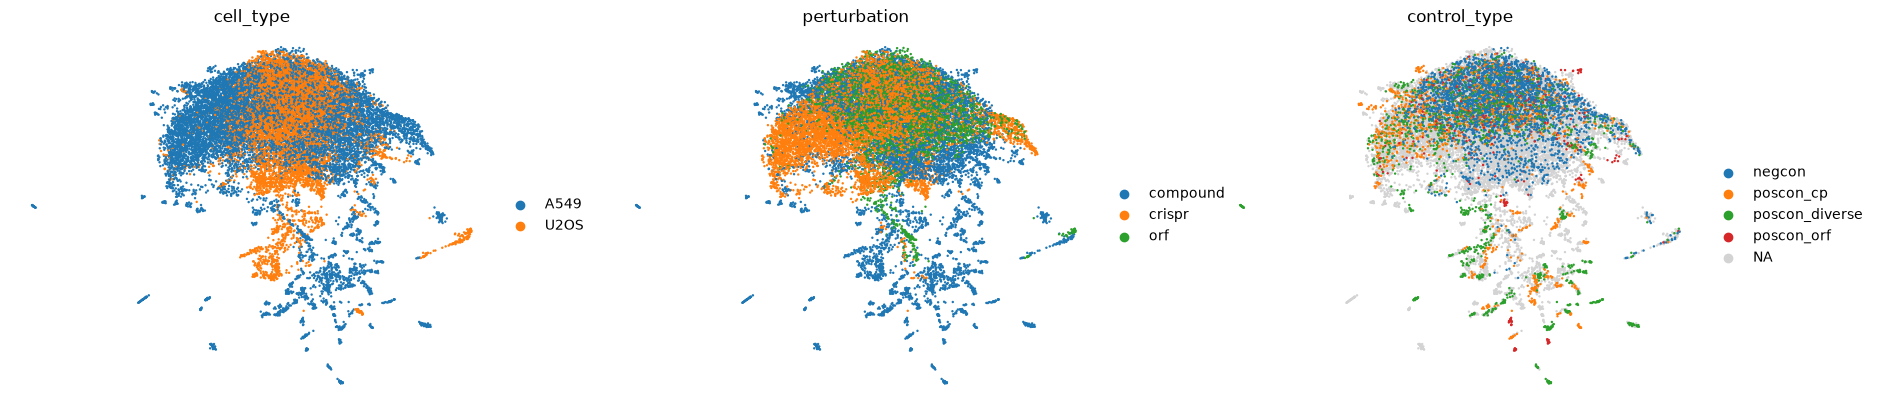

In [10]:
sc.pl.umap(adata, color=["cell_type", "perturbation", "control_type"], ncols=3, frameon=False, size=12)